Car Crash Severity Prediction

The aim of this project is to build machine learning classification models that predict the severity of car crashes using structured crash-related data. Accurate prediction of crash severity can help improve emergency response planning and road safety strategies.

1.Import Libraries

In [54]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and model selection
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Normal sklearn pipeline
from sklearn.pipeline import Pipeline

# Imbalanced-learn pipeline and SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Classification models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

2. Load the Train and Test Datasets

In [2]:
# Load the training and testing datasets
train_df = pd.read_csv("car_crash_train.csv")
test_df = pd.read_csv("car_crash_test.csv")

In [34]:
# Display the first rows of the training dataset
train_df.head()
# Check the shape of the dataset
print("Training dataset shape:", train_df.shape)

Training dataset shape: (4000, 19)
Testing dataset shape: (1000, 19)


In [35]:
# Check information about the training dataset
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float

In [33]:
# Display statistical summary of the training dataset
train_df.describe()

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m)
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,110.999750,89.979750,9.445500,48.698750,24.723000,0.101216,247.583500
std,52.227839,51.301514,5.718147,17.815972,14.211818,0.057820,143.478155
min,20.000000,0.000000,0.000000,18.000000,0.000000,0.000054,10.000000
25%,66.000000,45.000000,5.000000,34.000000,13.000000,0.050630,120.000000
50%,112.000000,89.500000,9.000000,49.000000,25.000000,0.101574,244.000000
75%,157.000000,134.000000,14.000000,64.000000,37.000000,0.151783,372.000000
max,199.000000,179.000000,19.000000,79.000000,49.000000,0.199936,499.000000


3.Exploratory Data Analysis

The EDA was performed to understand the structure of the training and testing datasets. Missing values, duplicate rows, numerical feature distributions, and target class distribution were checked. Since the test dataset contains labels, the labels will be separated from the test features and used only for final model evaluation. The target distribution is important because class imbalance can affect classification performance.

In [36]:
# Check missing values in the training dataset
train_df.isnull().sum()

,0
Crash Speed (km/h),0
Impact Angle (degrees),0
Airbag Deployed,0
Seatbelt Used,0
Weather Conditions,0
Road Conditions,0
Crash Type,0
Vehicle Type,0
Vehicle Age (years),0
Brake Condition,0


In [37]:
# Check duplicate rows in the training dataset
print("Duplicate rows in training dataset:", train_df.duplicated().sum())

Duplicate rows in training dataset: 0


In [10]:
# Check the distribution of the target variable in the training dataset
train_df["Severity"].value_counts()

,count
Severity,
Minor Injury,2756
Severe Injury,1038
Fatal,206


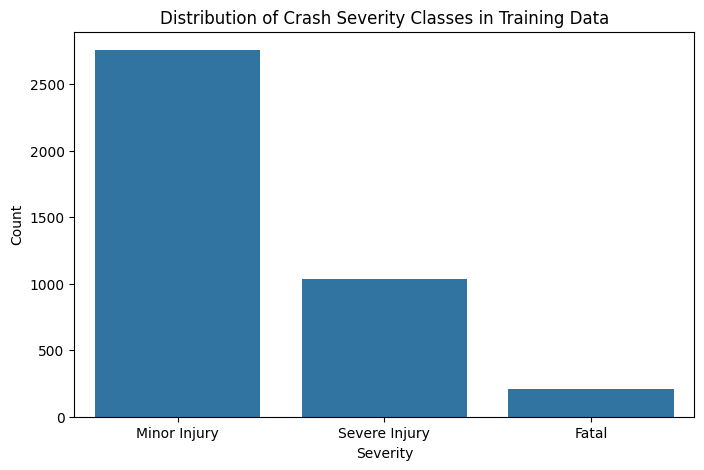

In [11]:
# Plot the distribution of crash severity classes in the training dataset
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x="Severity")
plt.title("Distribution of Crash Severity Classes in Training Data")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

In [38]:
# Select numerical columns from the training dataset
numerical_cols_eda = train_df.select_dtypes(include=["int64", "float64"]).columns

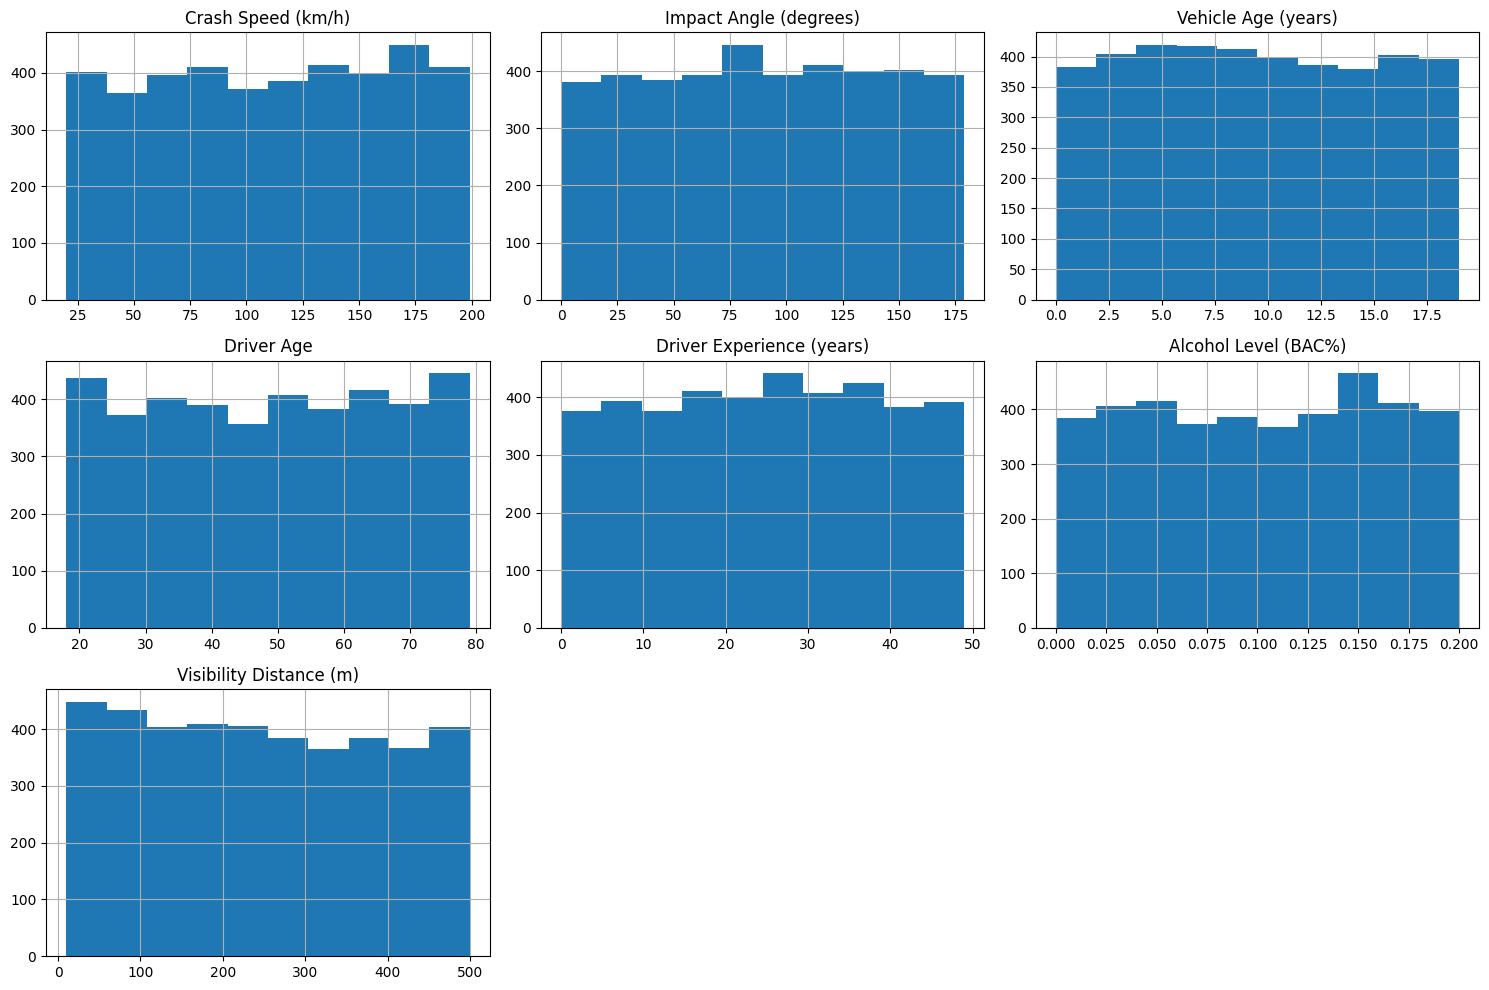

In [15]:
# Plot histograms for numerical columns
train_df[numerical_cols_eda].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

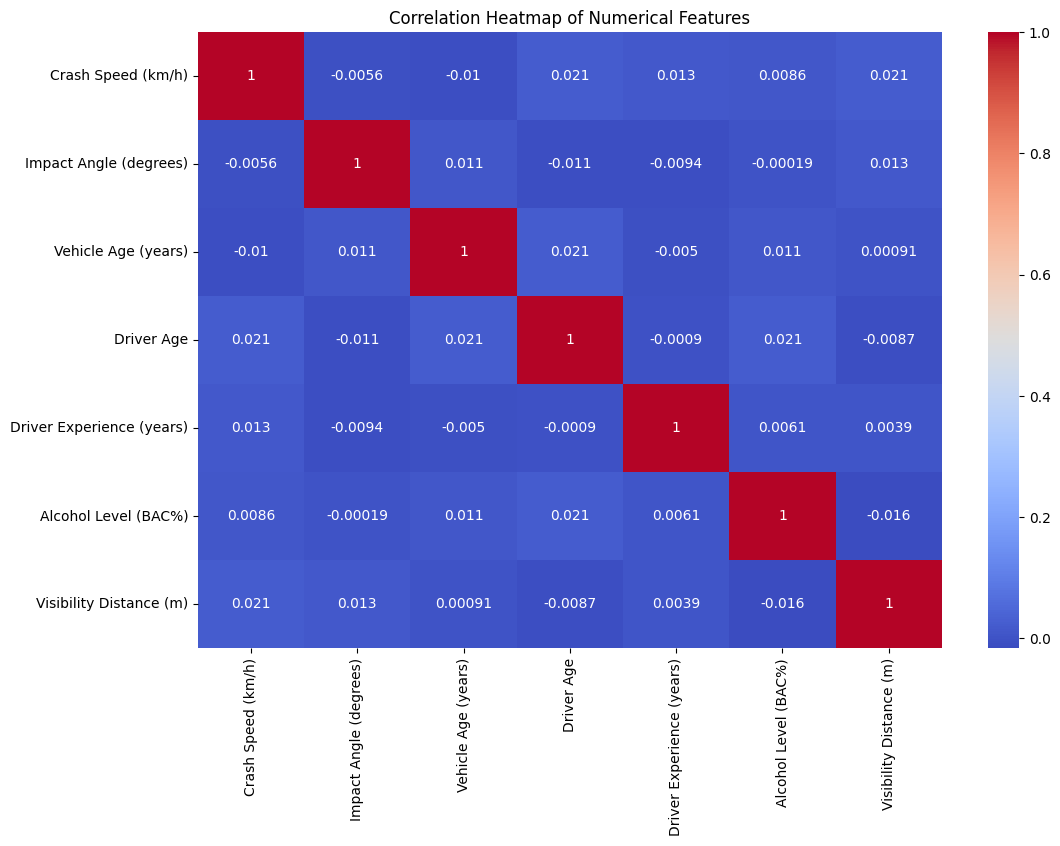

In [16]:
# Plot correlation heatmap for numerical features
plt.figure(figsize=(12, 8))
sns.heatmap(train_df[numerical_cols_eda].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

 4.Separate Features and Target

The label encoder was fitted only on the training labels. The same encoder was then used to transform the test labels. This avoids data leakage and ensures that both training and testing labels use the same numerical encoding.



In [39]:
# Define the target column
target_col = "Severity"

# Separate features and labels from the training dataset
X = train_df.drop(columns=[target_col])
y = train_df[target_col]

# Separate features and labels from the testing dataset
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

In [55]:
# Remove ID column from the training features if it exists
if "ID" in X.columns:
    X = X.drop(columns=["ID"])

# Remove ID column from the testing features if it exists
if "ID" in X_test.columns:
    X_test = X_test.drop(columns=["ID"])

In [56]:
# Create label encoder
label_encoder = LabelEncoder()

# Fit encoder on the training labels and transform them
y_encoded = label_encoder.fit_transform(y)

# Transform the test labels using the same encoder
y_test_encoded = label_encoder.transform(y_test)

# Display class mapping
print("Classes:", label_encoder.classes_)

Classes: ['Fatal' 'Minor Injury' 'Severe Injury']


In [47]:
from sklearn.model_selection import train_test_split

# Split the original training dataset into 80% training and 20% validation
X_train, X_val, y_train_encoded, y_val_encoded = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Training set shape: (3200, 18)
Validation set shape: (800, 18)
Test set shape: (1000, 18)


Preprocessing

In [59]:
# Select numerical columns from training features
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# Select categorical columns from training features
categorical_cols = X_train.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
Index(['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)',
       'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)',
       'Visibility Distance (m)'],
      dtype='object')

Categorical columns:
Index(['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions',
       'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition',
       'Tire Condition', 'Distraction Level', 'Time of Day',
       'Traffic Density'],
      dtype='object')


In [60]:
# Create OneHotEncoder in a way that works with newer and older sklearn versions
try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Numerical preprocessing:
# 1. Fill missing values using median
# 2. Scale numerical values
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# 1. Fill missing values using most frequent value
# 2. One-hot encode categorical values
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", onehot_encoder)
])

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

Cross-Validation Setup

In [52]:
# Create stratified cross-validation object
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Model Training and Evaluation

Model 1: KNN

In [61]:
# Create KNN pipeline with preprocessing and SMOTE
knn_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", KNeighborsClassifier())
])

# Define KNN hyperparameters
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

# Create GridSearchCV for KNN
knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

# Train KNN on the 80% training split
knn_search.fit(X_train, y_train_encoded)

# Predict on the 20% validation split
y_pred_knn = knn_search.predict(X_val)

# Evaluation
print("Best KNN Parameters:")
print(knn_search.best_params_)

print("\nBest KNN Cross-Validation Macro F1:")
print(knn_search.best_score_)

print("\nKNN Validation Accuracy:")
print(accuracy_score(y_val_encoded, y_pred_knn))

print("\nKNN Validation Classification Report:")
print(classification_report(
    y_val_encoded,
    y_pred_knn,
    target_names=label_encoder.classes_,
    zero_division=0
))

Best KNN Parameters:
{'model__metric': 'manhattan', 'model__n_neighbors': 7, 'model__weights': 'uniform'}

Best KNN Cross-Validation Macro F1:
0.32116786734438696

KNN Validation Accuracy:
0.45625

KNN Validation Classification Report:
               precision    recall  f1-score   support

        Fatal       0.05      0.17      0.08        41
 Minor Injury       0.70      0.52      0.60       551
Severe Injury       0.28      0.34      0.31       208

     accuracy                           0.46       800
    macro avg       0.34      0.34      0.33       800
 weighted avg       0.56      0.46      0.50       800



Model 2: Decision Tree

In [62]:
# Create Decision Tree pipeline with preprocessing and SMOTE
dt_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Define Decision Tree hyperparameters
dt_param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": [None, "balanced"]
}

# Create GridSearchCV for Decision Tree
dt_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

# Train Decision Tree on the 80% training split
dt_search.fit(X_train, y_train_encoded)

# Predict on the 20% validation split
y_pred_dt = dt_search.predict(X_val)

# Evaluation
print("Best Decision Tree Parameters:")
print(dt_search.best_params_)

print("\nBest Decision Tree Cross-Validation Macro F1:")
print(dt_search.best_score_)

print("\nDecision Tree Validation Accuracy:")
print(accuracy_score(y_val_encoded, y_pred_dt))

print("\nDecision Tree Validation Classification Report:")
print(classification_report(
    y_val_encoded,
    y_pred_dt,
    target_names=label_encoder.classes_,
    zero_division=0
))

Best Decision Tree Parameters:
{'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': 20, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}

Best Decision Tree Cross-Validation Macro F1:
0.33923095923423563

Decision Tree Validation Accuracy:
0.54125

Decision Tree Validation Classification Report:
               precision    recall  f1-score   support

        Fatal       0.02      0.02      0.02        41
 Minor Injury       0.69      0.67      0.68       551
Severe Injury       0.30      0.30      0.30       208

     accuracy                           0.54       800
    macro avg       0.33      0.33      0.33       800
 weighted avg       0.55      0.54      0.55       800



Model 3: Random Forest

In [63]:
# Create Random Forest pipeline with preprocessing and SMOTE
rf_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

# Define Random Forest hyperparameters
rf_param_grid = {
    "model__n_estimators": [100],
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": [None, "balanced"]
}

# Create GridSearchCV for Random Forest
rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

# Train Random Forest on the 80% training split
rf_search.fit(X_train, y_train_encoded)

# Predict on the 20% validation split
y_pred_rf = rf_search.predict(X_val)

# Evaluation
print("Best Random Forest Parameters:")
print(rf_search.best_params_)

print("\nBest Random Forest Cross-Validation Macro F1:")
print(rf_search.best_score_)

print("\nRandom Forest Validation Accuracy:")
print(accuracy_score(y_val_encoded, y_pred_rf))

print("\nRandom Forest Validation Classification Report:")
print(classification_report(
    y_val_encoded,
    y_pred_rf,
    target_names=label_encoder.classes_,
    zero_division=0
))

Best Random Forest Parameters:
{'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Random Forest Cross-Validation Macro F1:
0.2875998672110695

Random Forest Validation Accuracy:
0.67125

Random Forest Validation Classification Report:
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      0.97      0.80       551
Severe Injury       0.11      0.01      0.02       208

     accuracy                           0.67       800
    macro avg       0.26      0.33      0.27       800
 weighted avg       0.50      0.67      0.56       800



Model 4: Logistic Regression

In [64]:
# Create Logistic Regression pipeline with preprocessing and SMOTE
lr_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Define Logistic Regression hyperparameters
lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs"],
    "model__class_weight": [None, "balanced"]
}

# Create GridSearchCV for Logistic Regression
lr_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

# Train Logistic Regression on the 80% training split
lr_search.fit(X_train, y_train_encoded)

# Predict on the 20% validation split
y_pred_lr = lr_search.predict(X_val)

# Evaluation
print("Best Logistic Regression Parameters:")
print(lr_search.best_params_)

print("\nBest Logistic Regression Cross-Validation Macro F1:")
print(lr_search.best_score_)

print("\nLogistic Regression Validation Accuracy:")
print(accuracy_score(y_val_encoded, y_pred_lr))

print("\nLogistic Regression Validation Classification Report:")
print(classification_report(
    y_val_encoded,
    y_pred_lr,
    target_names=label_encoder.classes_,
    zero_division=0
))

Best Logistic Regression Parameters:
{'model__C': 1, 'model__class_weight': None, 'model__solver': 'lbfgs'}

Best Logistic Regression Cross-Validation Macro F1:
0.2558997263002746

Logistic Regression Validation Accuracy:
0.2975

Logistic Regression Validation Classification Report:
               precision    recall  f1-score   support

        Fatal       0.04      0.32      0.08        41
 Minor Injury       0.69      0.29      0.41       551
Severe Injury       0.24      0.32      0.27       208

     accuracy                           0.30       800
    macro avg       0.33      0.31      0.25       800
 weighted avg       0.54      0.30      0.36       800



Model 5: Naïve Bayes

In [65]:
# Create Naive Bayes pipeline with preprocessing and SMOTE
nb_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", GaussianNB())
])

# Define Naive Bayes hyperparameters
nb_param_grid = {
    "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
}

# Create GridSearchCV for Naive Bayes
nb_search = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

# Train Naive Bayes on the 80% training split
nb_search.fit(X_train, y_train_encoded)

# Predict on the 20% validation split
y_pred_nb = nb_search.predict(X_val)

# Evaluation
print("Best Naive Bayes Parameters:")
print(nb_search.best_params_)

print("\nBest Naive Bayes Cross-Validation Macro F1:")
print(nb_search.best_score_)

print("\nNaive Bayes Validation Accuracy:")
print(accuracy_score(y_val_encoded, y_pred_nb))

print("\nNaive Bayes Validation Classification Report:")
print(classification_report(
    y_val_encoded,
    y_pred_nb,
    target_names=label_encoder.classes_,
    zero_division=0
))

Best Naive Bayes Parameters:
{'model__var_smoothing': 1e-09}

Best Naive Bayes Cross-Validation Macro F1:
0.2773069945519734

Naive Bayes Validation Accuracy:
0.36

Naive Bayes Validation Classification Report:
               precision    recall  f1-score   support

        Fatal       0.04      0.27      0.06        41
 Minor Injury       0.69      0.43      0.53       551
Severe Injury       0.25      0.18      0.21       208

     accuracy                           0.36       800
    macro avg       0.33      0.29      0.27       800
 weighted avg       0.54      0.36      0.42       800



Model Comparison Table

In [66]:
# Store validation predictions for all models
model_predictions = {
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Logistic Regression": y_pred_lr,
    "Naive Bayes": y_pred_nb
}

# Create a list to store evaluation results
results = []

# Calculate evaluation metrics for each model
for model_name, y_pred in model_predictions.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_val_encoded, y_pred),
        "Precision Weighted": precision_score(y_val_encoded, y_pred, average="weighted", zero_division=0),
        "Recall Weighted": recall_score(y_val_encoded, y_pred, average="weighted", zero_division=0),
        "F1 Weighted": f1_score(y_val_encoded, y_pred, average="weighted", zero_division=0),
        "F1 Macro": f1_score(y_val_encoded, y_pred, average="macro", zero_division=0)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort by Macro F1 because the dataset is imbalanced
results_df = results_df.sort_values(by="F1 Macro", ascending=False)

# Display results
results_df

,Model,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,Decision Tree,0.54125,0.550564,0.54125,0.545835,0.332430
0,KNN,0.45625,0.560060,0.45625,0.496517,0.327453
2,Random Forest,0.67125,0.499780,0.67125,0.558272,0.273843
4,Naive Bayes,0.36000,0.541681,0.36000,0.424946,0.269378
3,Logistic Regression,0.29750,0.542431,0.29750,0.355539,0.252490


In [67]:
# Store trained GridSearchCV objects
trained_models = {
    "KNN": knn_search,
    "Decision Tree": dt_search,
    "Random Forest": rf_search,
    "Logistic Regression": lr_search,
    "Naive Bayes": nb_search
}

# Get the best model name from the comparison table
best_model_name = results_df.iloc[0]["Model"]

# Get the best trained model object
best_model = trained_models[best_model_name].best_estimator_

print("Best model based on validation Macro F1:", best_model_name)

Best model based on validation Macro F1: Decision Tree


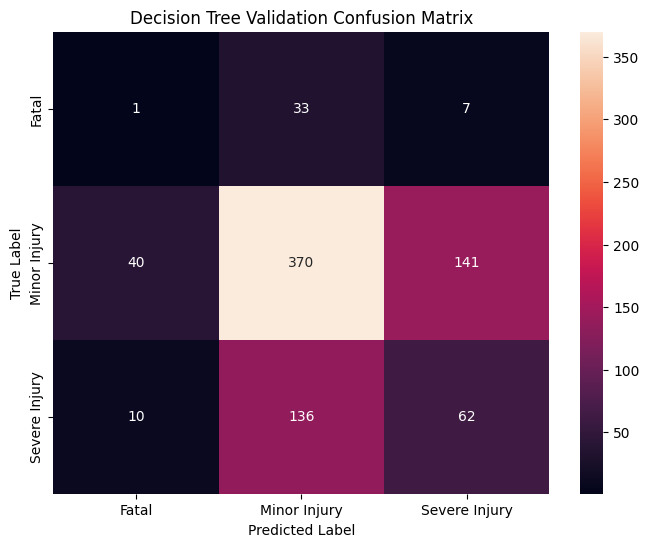

In [68]:
# Get predictions of the best model on validation set
best_val_predictions = model_predictions[best_model_name]

# Create confusion matrix
cm = confusion_matrix(y_val_encoded, best_val_predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"{best_model_name} Validation Confusion Matrix")
plt.show()

In [69]:
# Retrain the best model on the full training dataset
best_model.fit(X, y_encoded)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)',
       'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)',
       'Visibility Distance (m)'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(st...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions',
       'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition',
       'Tire Condition', 'Distraction Level', 'Time of Day',
       'Traffic Density'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 DecisionTreeClassifier(max_depth=20, min_samples_leaf=4,
                                        random_state=42))])

In [70]:
# Predict on the final test dataset
final_test_predictions = best_model.predict(X_test)

# Evaluate final model on the test set
print("Final Test Accuracy:")
print(accuracy_score(y_test_encoded, final_test_predictions))

print("\nFinal Test Classification Report:")
print(classification_report(
    y_test_encoded,
    final_test_predictions,
    target_names=label_encoder.classes_,
    zero_division=0
))

Final Test Accuracy:
0.567

Final Test Classification Report:
               precision    recall  f1-score   support

        Fatal       0.05      0.07      0.06        41
 Minor Injury       0.72      0.71      0.72       710
Severe Injury       0.25      0.24      0.24       249

     accuracy                           0.57      1000
    macro avg       0.34      0.34      0.34      1000
 weighted avg       0.58      0.57      0.57      1000



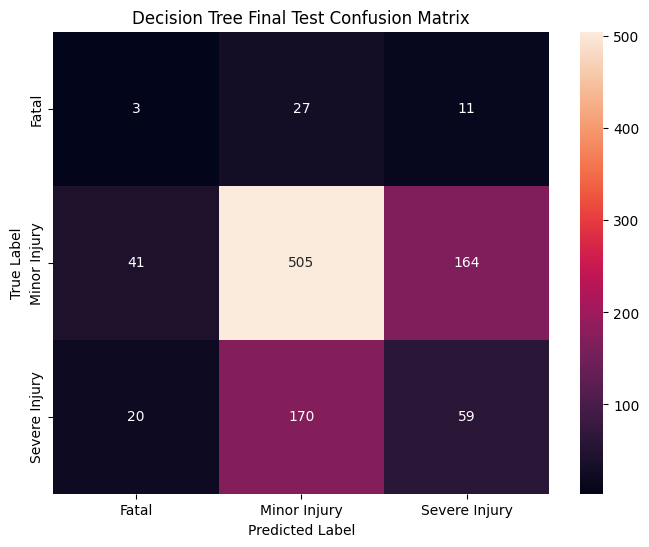

In [71]:
# Final test confusion matrix
final_cm = confusion_matrix(y_test_encoded, final_test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"{best_model_name} Final Test Confusion Matrix")
plt.show()

In [72]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Store the best estimator from each trained GridSearchCV model
best_estimators = {
    "KNN": knn_search.best_estimator_,
    "Decision Tree": dt_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "Logistic Regression": lr_search.best_estimator_,
    "Naive Bayes": nb_search.best_estimator_
}

# Lists to store results and predictions
test_results = []
test_predictions = {}

# Train each best model on the FULL training dataset and evaluate on the test dataset
for model_name, model in best_estimators.items():

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    # Clone the model so we do not overwrite the original validation model
    final_model = clone(model)

    # Retrain the model on the full training dataset
    final_model.fit(X, y_encoded)

    # Predict on the test dataset
    y_pred_test = final_model.predict(X_test)

    # Store predictions
    test_predictions[model_name] = y_pred_test

    # Calculate metrics
    accuracy = accuracy_score(y_test_encoded, y_pred_test)
    precision_weighted = precision_score(y_test_encoded, y_pred_test, average="weighted", zero_division=0)
    recall_weighted = recall_score(y_test_encoded, y_pred_test, average="weighted", zero_division=0)
    f1_weighted = f1_score(y_test_encoded, y_pred_test, average="weighted", zero_division=0)
    f1_macro = f1_score(y_test_encoded, y_pred_test, average="macro", zero_division=0)

    # Store results
    test_results.append({
        "Model": model_name,
        "Test Accuracy": accuracy,
        "Test Precision Weighted": precision_weighted,
        "Test Recall Weighted": recall_weighted,
        "Test F1 Weighted": f1_weighted,
        "Test F1 Macro": f1_macro
    })

    # Print classification report
    print("Test Accuracy:", accuracy)
    print("\nClassification Report:")
    print(classification_report(
        y_test_encoded,
        y_pred_test,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

KNN
Test Accuracy: 0.475

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.06      0.24      0.10        41
 Minor Injury       0.70      0.57      0.63       710
Severe Injury       0.24      0.25      0.24       249

     accuracy                           0.47      1000
    macro avg       0.33      0.35      0.32      1000
 weighted avg       0.56      0.47      0.51      1000

Decision Tree
Test Accuracy: 0.567

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.05      0.07      0.06        41
 Minor Injury       0.72      0.71      0.72       710
Severe Injury       0.25      0.24      0.24       249

     accuracy                           0.57      1000
    macro avg       0.34      0.34      0.34      1000
 weighted avg       0.58      0.57      0.57      1000

Random Forest
Test Accuracy: 0.698

Classification Report:
               precision    recall  f1-score   support

 

In [73]:
# Convert test results into a DataFrame
test_results_df = pd.DataFrame(test_results)

# Sort by Macro F1 because the dataset is imbalanced
test_results_df = test_results_df.sort_values(by="Test F1 Macro", ascending=False)

# Display comparison table
test_results_df

,Model,Test Accuracy,Test Precision Weighted,Test Recall Weighted,Test F1 Weighted,Test F1 Macro
1,Decision Tree,0.567,0.575459,0.567,0.571036,0.338916
0,KNN,0.475,0.561186,0.475,0.510635,0.322661
2,Random Forest,0.698,0.568358,0.698,0.593809,0.288332
3,Logistic Regression,0.329,0.580039,0.329,0.390280,0.275976
4,Naive Bayes,0.379,0.549211,0.379,0.440263,0.274767


In [74]:
best_test_model_name = test_results_df.iloc[0]["Model"]

print("Best model on test data:", best_test_model_name)
print("Best test Macro F1:", test_results_df.iloc[0]["Test F1 Macro"])

Best model on test data: Decision Tree
Best test Macro F1: 0.338915575262416


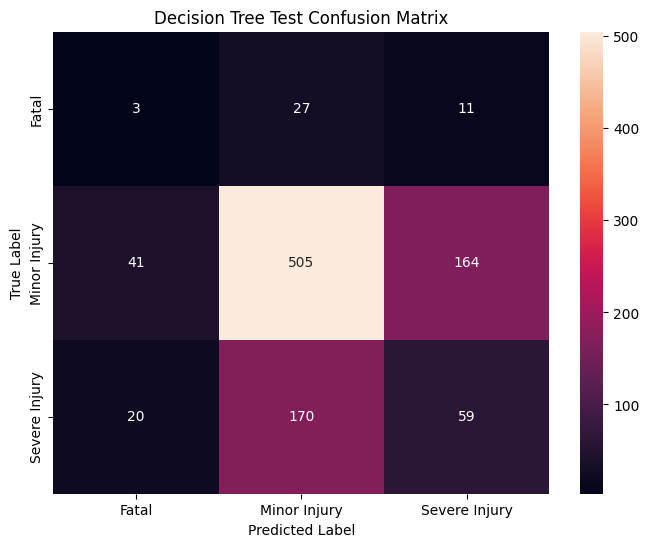

In [75]:
# Get predictions of the best test model
best_test_predictions = test_predictions[best_test_model_name]

# Create confusion matrix
cm = confusion_matrix(y_test_encoded, best_test_predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"{best_test_model_name} Test Confusion Matrix")
plt.show()